Initial Shape: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


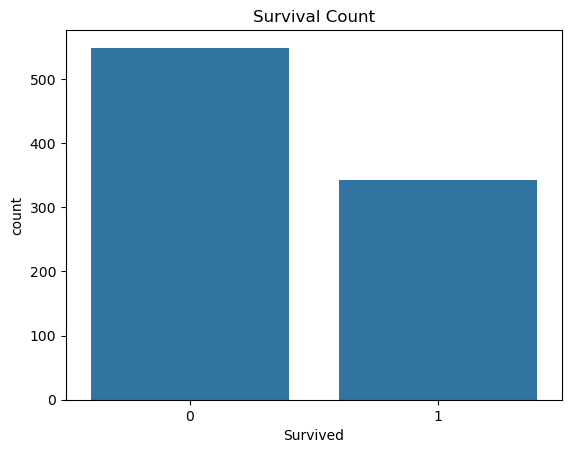

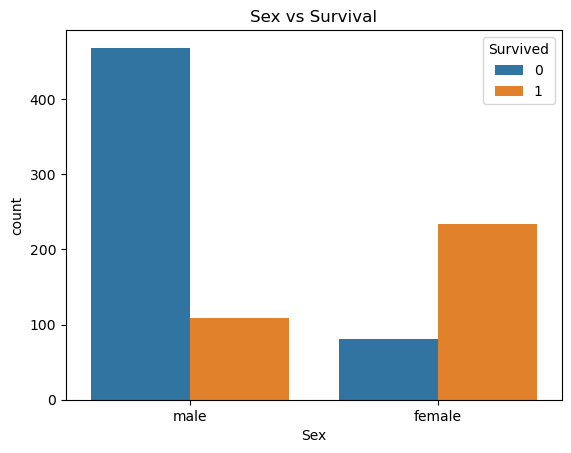

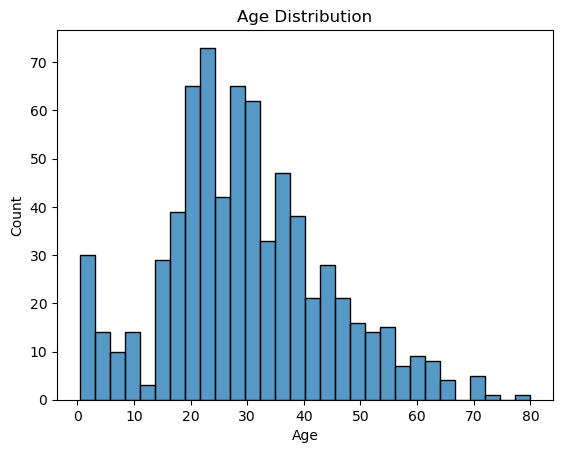

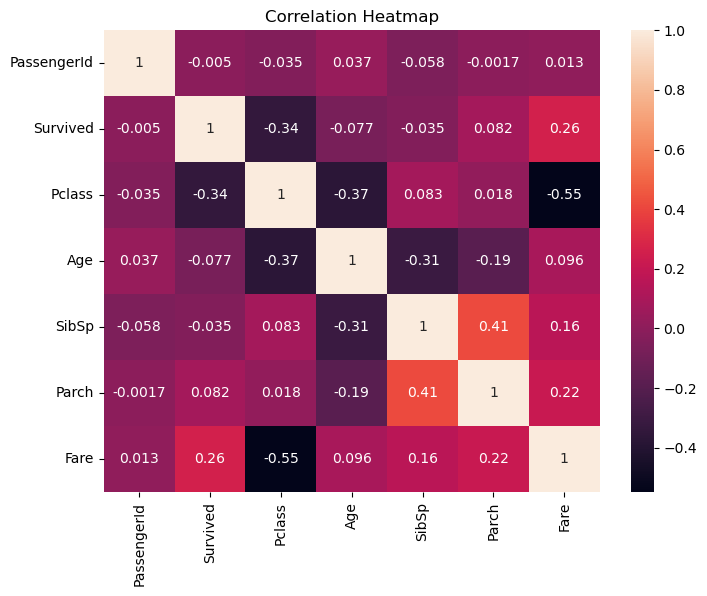


Missing Values Before:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values After:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Train Shape: (712, 8)
Test Shape: (179, 8)

Model Accuracy: 0.8212290502793296

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



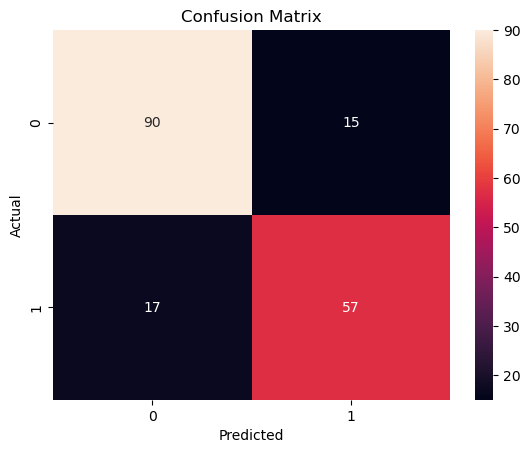


Pipeline Saved Successfully!

New Prediction (0 = No, 1 = Yes): [1]


In [3]:
# ==========================================
# TITANIC ML PROJECT 
# ==========================================

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# ==============================
# 2. CREATE OUTPUT FOLDER
# ==============================
os.makedirs("outputs", exist_ok=True)

# ==============================
# 3. LOAD DATA
# ==============================
df = pd.read_csv("titanic.csv")

print("Initial Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

# ==============================
# 4. EDA (VISUALIZATION)
# ==============================

# Survival Count
plt.figure()
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.savefig("outputs/survival_count.png")
plt.show()
plt.close()

# Sex vs Survival
plt.figure()
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Sex vs Survival")
plt.savefig("outputs/sex_survival.png")
plt.show()
plt.close()

# Age Distribution
plt.figure()
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")
plt.savefig("outputs/age_distribution.png")
plt.show()
plt.close()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("outputs/correlation.png")
plt.show()
plt.close()

# ==============================
# 5. DATA CLEANING
# ==============================

print("\nMissing Values Before:\n", df.isnull().sum())

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin (too many missing)
df.drop("Cabin", axis=1, inplace=True)

# Remove duplicates
df = df.drop_duplicates()

print("\nMissing Values After:\n", df.isnull().sum())

# ==============================
# 6. FEATURE ENGINEERING
# ==============================

# Create Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Drop unnecessary columns
df.drop(["Name", "Ticket", "PassengerId"], axis=1, inplace=True)

# ==============================
# 7. FEATURES & TARGET
# ==============================
X = df.drop("Survived", axis=1)
y = df["Survived"]

# ==============================
# 8. PREPROCESSING
# ==============================
categorical_cols = ["Sex", "Embarked"]
numeric_cols = ["Age", "Fare", "FamilySize", "Pclass"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# ==============================
# 9. MODEL PIPELINE
# ==============================
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# ==============================
# 10. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==============================
# 11. TRAIN MODEL
# ==============================
pipeline.fit(X_train, y_train)

# ==============================
# 12. PREDICTIONS & EVALUATION
# ==============================
predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("\nModel Accuracy:", accuracy)

print("\nClassification Report:\n", classification_report(y_test, predictions))

# ==============================
# 13. CONFUSION MATRIX (VISUAL)
# ==============================
cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("outputs/confusion_matrix.png")
plt.show()
plt.close()

# ==============================
# 14. SAVE CLEAN DATA
# ==============================
df.to_csv("outputs/clean_titanic.csv", index=False)

# ==============================
# 15. SAVE MODEL PIPELINE
# ==============================
joblib.dump(pipeline, "outputs/titanic_pipeline.pkl")

print("\nPipeline Saved Successfully!")

# ==============================
# 16. TEST ON NEW DATA
# ==============================
new_data = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [25],
    "Fare": [100],
    "Embarked": ["C"],
    "FamilySize": [1]
})

new_prediction = pipeline.predict(new_data)

print("\nNew Prediction (0 = No, 1 = Yes):", new_prediction)